# SolarMarket-Sizer
### Renewable Energy Sizing & Sensitivity Analysis for an Urban Market

This notebook walks through the full analysis:
1. Define an estimated hourly load profile for the market
2. Pull solar resource / PV generation data from PVGIS for the chosen site
3. Run a PV + battery dispatch simulation
4. Sweep across system sizes and visualize the tradeoffs
5. Summarize the recommended sizing and its assumptions/limitations

See `README.md` for the full methodology write-up and known simplifications.


In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_profile import (
    generate_year_profile,
    apply_demand_scenario,
)
from src.pvgis import fetch_pvgis_hourly, load_pvgis_csv, scale_pv_output
from src.battery_model import simulate_pv_battery, summarize_run, sensitivity_sweep

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Site & market assumptions

Fill these in for your chosen market. Keep them explicit — this is the
single biggest source of uncertainty in the whole analysis, so being
transparent about assumptions matters more than false precision.


In [3]:
# --- SITE ---
SITE_NAME = "Example Market, Lagos, Nigeria"   # <-- update
LATITUDE = 6.5244                               # <-- update
LONGITUDE = 3.3792                              # <-- update

# --- MARKET LOAD ASSUMPTIONS ---
NUM_STALLS = 80
STALL_LOAD_KW = 0.35

LIGHTING_KW = 5.0
REFRIGERATION_KW = 3.0
WATER_PUMP_KW = 2.0
SECURITY_KW = 1.0
OTHER_FIXED_KW = 2.0

OPEN_HOUR = 6
CLOSE_HOUR = 19
MARKET_DAYS = [0, 1, 2, 3, 4, 5]   # closed Sundays (0=Mon ... 6=Sun)

# Demand scenarios
DEMAND_SCENARIOS = {
    "low": 0.80,
    "base": 1.00,
    "high": 1.20,
}

print("Market demand assumptions configured.")
print(f"Number of stalls: {NUM_STALLS}")
print(f"Base stall load: {STALL_LOAD_KW:.2f} kW/stall")
print(f"Demand scenarios: {DEMAND_SCENARIOS}")


Market demand assumptions configured.
Number of stalls: 80
Base stall load: 0.35 kW/stall
Demand scenarios: {'low': 0.8, 'base': 1.0, 'high': 1.2}


## 2. Build the hourly load profile

The market demand profile is synthetic and is constructed from explicit end-use assumptions rather than metered electricity data. Three demand scenarios are retained for later sensitivity analysis:

- **Low:** 80% of the base demand
- **Base:** 100% of the base demand
- **High:** 120% of the base demand


Low scenario:
  Peak demand: 32.8 kW
  Annual demand: 158,883 kWh

Base scenario:
  Peak demand: 41.0 kW
  Annual demand: 198,603 kWh

High scenario:
  Peak demand: 49.2 kW
  Annual demand: 238,324 kWh

Base scenario selected for the existing PV/battery workflow.


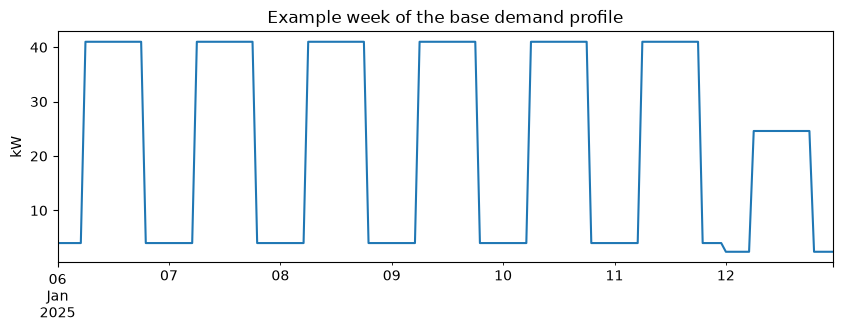

In [4]:
# Generate the base end-use demand profile
base_load_df = generate_year_profile(
    num_stalls=NUM_STALLS,
    stall_load_kw=STALL_LOAD_KW,
    lighting_kw=LIGHTING_KW,
    refrigeration_kw=REFRIGERATION_KW,
    water_pump_kw=WATER_PUMP_KW,
    security_kw=SECURITY_KW,
    other_fixed_kw=OTHER_FIXED_KW,
    open_hour=OPEN_HOUR,
    close_hour=CLOSE_HOUR,
    market_days=MARKET_DAYS,
    periods_days=365,
)

# Create low, base, and high demand scenarios
load_profiles = {}

for scenario, factor in DEMAND_SCENARIOS.items():
    load_profiles[scenario] = apply_demand_scenario(
        base_load_df,
        scenario=scenario,
        low_factor=DEMAND_SCENARIOS["low"],
        high_factor=DEMAND_SCENARIOS["high"],
    )

    profile = load_profiles[scenario]

    print(f"{scenario.capitalize()} scenario:")
    print(
        f"  Peak demand: "
        f"{profile['total_load_kw'].max():.1f} kW"
    )
    print(
        f"  Annual demand: "
        f"{profile['total_load_kw'].sum():,.0f} kWh"
    )
    print()

# Use the base scenario for the existing single-scenario workflow
load_df = load_profiles["base"]

# The battery model expects a column called load_kw
load_df["load_kw"] = load_df["total_load_kw"]

print("Base scenario selected for the existing PV/battery workflow.")

load_df["load_kw"].loc["2025-01-06":"2025-01-12"].plot(
    figsize=(10, 3), title="Example week of the base demand profile"
)
plt.ylabel("kW")
plt.show()


## 3. Solar resource data (PVGIS)

`fetch_pvgis_hourly()` makes a live call to the PVGIS API and needs
internet access. If you're working somewhere without external network
access, download the CSV manually from
https://re.jrc.ec.europa.eu/pvg_tools/en/ for your coordinates and load it
with `load_pvgis_csv("../data/pvgis_raw.csv")` instead — both paths are
shown below.


In [9]:
# --- Option A: live API call ---
pvgis_df = fetch_pvgis_hourly(
    lat=LATITUDE,
    lon=LONGITUDE,
    peakpower_kw=1.0,   # 1 kWp reference system; we scale this later
    tilt_deg=15,        # roughly latitude-appropriate; adjust per site
    azimuth_deg=0,      # 0 = south-facing
    year_start=2019,
    year_end=2019,
)

# --- Option B: manually downloaded CSV  ---


import pandas as pd

#pvgis_path = r"C:\Users\JOSH\OneDrive\Documents\SolarMarket-Sizer 1\data\pvgis_raw.csv"
#pvgis_df = pd.read_csv(pvgis_path, skiprows=10)

pvgis_df.tail()

,poa_global_wm2,pv_power_w,temp_air_c
time,,,
2019-12-31 19:06:00,0.0,0.0,27.94
2019-12-31 20:06:00,0.0,0.0,27.36
2019-12-31 21:06:00,0.0,0.0,26.92
2019-12-31 22:06:00,0.0,0.0,26.61
2019-12-31 23:06:00,0.0,0.0,26.23


Annual yield per kWp installed (kWh/kWp): 1329.0


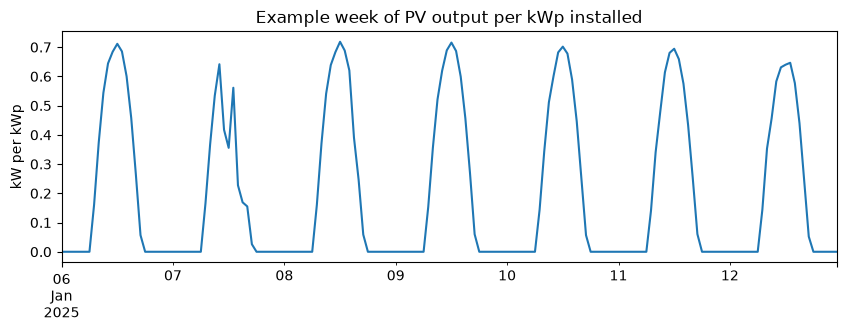

In [10]:
# Reindex PVGIS output onto the same calendar year as the load profile so
# the two series line up hour-for-hour (PVGIS years won't match load_df's
# 2025 index by default).
pv_1kwp = pvgis_df["pv_power_w"] / 1000.0   # convert W -> kW
pv_1kwp.index = load_df.index[: len(pv_1kwp)]  # align lengths/calendar

print("Annual yield per kWp installed (kWh/kWp):", round(pv_1kwp.sum(), 0))
pv_1kwp.loc["2025-01-06":"2025-01-12"].plot(
    figsize=(10, 3), title="Example week of PV output per kWp installed"
)
plt.ylabel("kW per kWp")
plt.show()


## 4. Single-scenario dispatch simulation

Pick one PV size and one battery size to sanity-check the dispatch logic
before running the full sweep.


In [11]:
TEST_PV_KWP = 25
TEST_BATTERY_KWH = 20

test_pv_series = pv_1kwp * TEST_PV_KWP

sim = simulate_pv_battery(
    load_kw=load_profiles["base"]["load_kw"],
    pv_gen_kw=test_pv_series,
    battery_capacity_kwh=TEST_BATTERY_KWH,
    battery_power_kw=TEST_BATTERY_KWH * 0.5,
)

kpis = summarize_run(sim)
for k, v in kpis.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")


total_load_kwh: 198603.400
total_pv_generation_kwh: 33213.724
total_grid_import_kwh: 165382.087
total_curtailed_kwh: 0.000
total_battery_charge_kwh: 0.000
total_battery_discharge_kwh: 7.589
renewable_fraction: 0.167
grid_dependency: 0.833
curtailment_fraction: 0.000
shortage_hours: 8759
loss_of_load_probability: 1.000
max_consecutive_shortage_hours: 8759


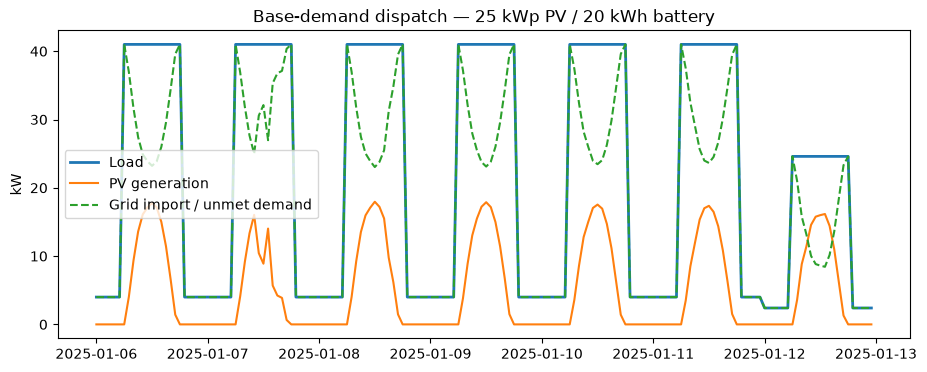

In [12]:
week = sim.loc["2025-01-06":"2025-01-12"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(week.index, week["load_kw"], label="Load", linewidth=2)
ax.plot(week.index, week["pv_gen_kw"], label="PV generation", linewidth=1.5)
ax.plot(week.index, week["grid_import_kw"], label="Grid import / unmet demand", linestyle="--")
ax.set_ylabel("kW")
ax.set_title(f"Base-demand dispatch — {TEST_PV_KWP} kWp PV / {TEST_BATTERY_KWH} kWh battery")
ax.legend()
plt.show()


In [7]:
# Summary of demand scenarios
scenario_summary = pd.DataFrame([
    {
        "scenario": scenario,
        "factor": factor,
        "peak_demand_kw": load_profiles[scenario]["total_load_kw"].max(),
        "annual_demand_kwh": load_profiles[scenario]["total_load_kw"].sum(),
    }
    for scenario, factor in DEMAND_SCENARIOS.items()
])

scenario_summary


,scenario,factor,peak_demand_kw,annual_demand_kwh
0,low,0.8,32.8,158882.72
1,base,1.0,41.0,198603.40
2,high,1.2,49.2,238324.08


## 5. Sensitivity sweep across PV and battery sizes

The first sweep below uses the **base demand scenario**. The low/base/high demand scenarios are retained in `load_profiles` and will be propagated into a multi-scenario sizing analysis in the next project step.

*** Update `pv_cost_per_kwp` and `battery_cost_per_kwh` below with current benchmark figures (e.g. from IRENA or NREL cost reports) before citing the capex numbers anywhere. The defaults are placeholders. ***


In [ ]:
PV_SIZES_KWP = [10, 20, 30, 40, 50, 75, 100]
BATTERY_SIZES_KWH = [0, 10, 20, 40, 60, 100]

sweep_df = sensitivity_sweep(
    load_kw=load_df["load_kw"],
    pv_gen_per_kwp=pv_1kwp,
    pv_sizes_kwp=PV_SIZES_KWP,
    battery_sizes_kwh=BATTERY_SIZES_KWH,
    pv_cost_per_kwp=700,        # PLACEHOLDER - update with current benchmark
    battery_cost_per_kwh=300,   # PLACEHOLDER - update with current benchmark
)

from pathlib import Path
Path("../outputs").mkdir(parents=True, exist_ok=True)
sweep_df.to_csv("../outputs/sensitivity_sweep_results.csv", index=False)
sweep_df.head(10)


,pv_size_kwp,battery_size_kwh,total_load_kwh,total_pv_generation_kwh,total_grid_import_kwh,total_curtailed_kwh,total_battery_charge_kwh,total_battery_discharge_kwh,renewable_fraction,grid_dependency,curtailment_fraction,shortage_hours,loss_of_load_probability,max_consecutive_shortage_hours,capex_estimate
0,10,0,198603.4,13285.4896,185317.910400,0.0,0.0,0.000000,0.066895,0.933105,0.0,8760,1.000000,8760,7000
1,10,0,198603.4,13285.4896,185317.910400,0.0,0.0,0.000000,0.066895,0.933105,0.0,8760,1.000000,8760,7000
2,10,10,198603.4,13285.4896,185314.115667,0.0,0.0,3.794733,0.066914,0.933086,0.0,8760,1.000000,8760,10000
3,10,10,198603.4,13285.4896,185314.115667,0.0,0.0,3.794733,0.066914,0.933086,0.0,8760,1.000000,8760,10000
4,10,20,198603.4,13285.4896,185310.320934,0.0,0.0,7.589466,0.066933,0.933067,0.0,8759,0.999886,8759,13000
5,10,20,198603.4,13285.4896,185310.320934,0.0,0.0,7.589466,0.066933,0.933067,0.0,8759,0.999886,8759,13000
6,10,40,198603.4,13285.4896,185302.731467,0.0,0.0,15.178933,0.066971,0.933029,0.0,8757,0.999658,8757,19000
7,10,40,198603.4,13285.4896,185302.731467,0.0,0.0,15.178933,0.066971,0.933029,0.0,8757,0.999658,8757,19000
8,10,60,198603.4,13285.4896,185295.142001,0.0,0.0,22.768399,0.067009,0.932991,0.0,8755,0.999429,8755,25000
9,10,60,198603.4,13285.4896,185295.142001,0.0,0.0,22.768399,0.067009,0.932991,0.0,8755,0.999429,8755,25000


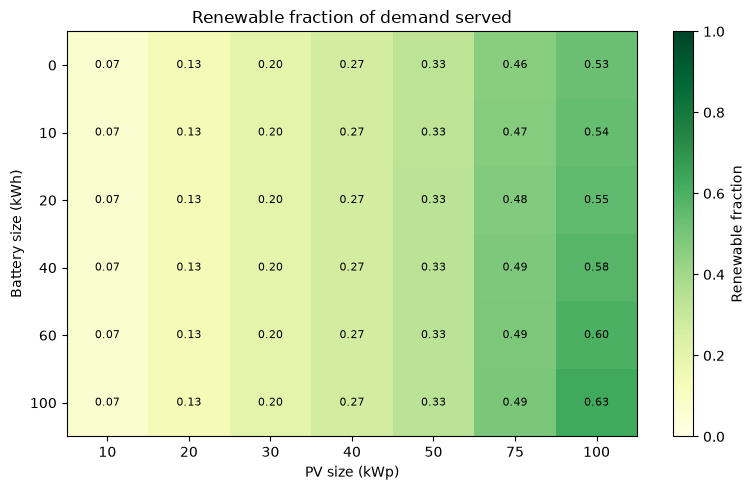

In [22]:
pivot = sweep_df.pivot_table(
    index="battery_size_kwh",
    columns="pv_size_kwp",
    values="renewable_fraction",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("PV size (kWp)")
ax.set_ylabel("Battery size (kWh)")
ax.set_title("Renewable fraction of demand served")
fig.colorbar(im, label="Renewable fraction")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/renewable_fraction_heatmap.png", dpi=150)
plt.show()


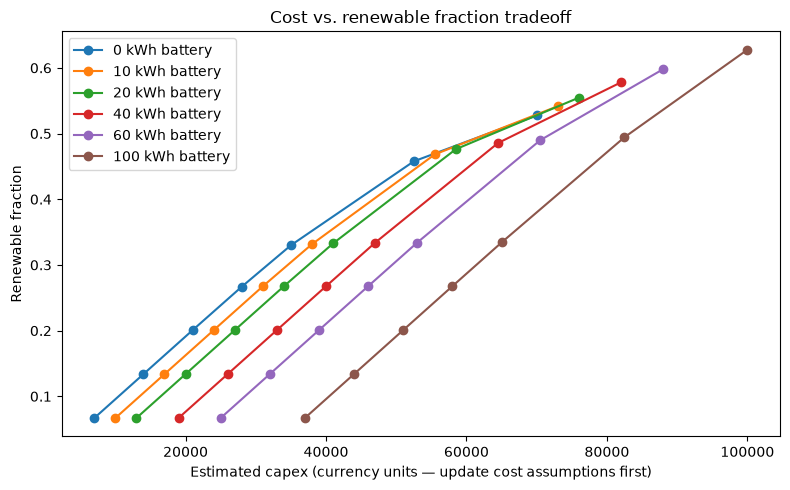

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
for batt in BATTERY_SIZES_KWH:
    subset = sweep_df[sweep_df["battery_size_kwh"] == batt]
    ax.plot(subset["capex_estimate"], subset["renewable_fraction"], marker="o", label=f"{batt} kWh battery")

ax.set_xlabel("Estimated capex (currency units — update cost assumptions first)")
ax.set_ylabel("Renewable fraction")
ax.set_title("Cost vs. renewable fraction tradeoff")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/cost_vs_renewable_fraction.png", dpi=150)
plt.show()


## 6. Marginal returns: where does battery storage actually start paying off?

A first look at the heatmap above shows something worth stating explicitly:
**at small PV sizes, adding a battery barely moves the renewable fraction at
all.** That's not a modeling error — a battery can only store *surplus* PV
generation, and if the PV system rarely produces more than the market is
drawing at that moment, there's nothing for it to charge from. Storage only
starts earning its cost once PV capacity is large enough to routinely
overshoot demand.

The cell below quantifies this by computing the renewable-fraction gain
per €1,000 of estimated capex, relative to the smallest system in the
sweep. Diminishing returns should be visible as PV/battery size increases.


In [24]:
baseline = sweep_df.loc[sweep_df["capex_estimate"].idxmin()]

sweep_df["delta_renewable_fraction"] = (
    sweep_df["renewable_fraction"] - baseline["renewable_fraction"]
)
sweep_df["delta_capex"] = sweep_df["capex_estimate"] - baseline["capex_estimate"]
sweep_df["renewable_fraction_gain_per_1000"] = (
    sweep_df["delta_renewable_fraction"] / (sweep_df["delta_capex"] / 1000)
).replace([float("inf"), -float("inf")], pd.NA)

sweep_df.sort_values("renewable_fraction_gain_per_1000", ascending=False).head(10)[
    ["pv_size_kwp", "battery_size_kwh", "renewable_fraction",
     "curtailment_fraction", "capex_estimate", "renewable_fraction_gain_per_1000"]
]


,pv_size_kwp,battery_size_kwh,renewable_fraction,curtailment_fraction,capex_estimate,renewable_fraction_gain_per_1000
12,30,0,0.200684,0.000000,21000,0.009556
6,20,0,0.133789,0.000000,14000,0.009556
18,40,0,0.266847,0.002731,28000,0.009522
24,50,0,0.329936,0.013563,35000,0.009394
30,75,0,0.457714,0.087690,52500,0.008589
25,50,10,0.331596,0.008115,38000,0.008539
19,40,10,0.267469,0.000229,31000,0.008357
31,75,10,0.468329,0.064224,55500,0.008277
32,75,20,0.476302,0.046610,58500,0.007950
13,30,10,0.200703,0.000000,24000,0.007871


## 7. Pick a recommended system size and summarize

Rather than chasing a single fixed renewable-fraction target (a naive
"75% or bust" threshold may not even be reachable — check the max value in
`sweep_df["renewable_fraction"]` before assuming it is), this project
selects **two** candidate systems and lets the tradeoff itself be the
finding:

- **Cost-efficient pick**: the system with the best renewable-fraction
  gain per €1,000 spent, among options with low curtailment (< 5%) — the
  point where you're not yet paying for wasted generation.
- **Renewable-maximizing pick**: the system that reaches the highest
  renewable fraction anywhere in the sweep, accepting that this will come
  with higher curtailment and a worse cost-per-percentage-point.

Presenting both, rather than a single number, is a more defensible planning
conclusion — and a better story for a portfolio project: it shows you can
reason about a tradeoff rather than just optimizing one metric in isolation.


In [25]:
MIN_RENEWABLE_FRACTION = 0.30   # floor so the "cheapest first unit" doesn't win by default
MAX_ACCEPTABLE_CURTAILMENT = 0.05  # 5% — adjust based on your own judgement

# Without a minimum renewable-fraction floor, the gain-per-euro metric
# always favors the very first, smallest increment of PV (the first kWp
# is always the "cheapest" percentage point from a zero baseline) — which
# isn't a usable recommendation. The floor keeps the pick meaningful.
viable = sweep_df[
    (sweep_df["curtailment_fraction"] <= MAX_ACCEPTABLE_CURTAILMENT)
    & (sweep_df["renewable_fraction"] >= MIN_RENEWABLE_FRACTION)
]

if viable.empty:
    print(
        "No system in the sweep meets both thresholds "
        f"(curtailment <= {MAX_ACCEPTABLE_CURTAILMENT:.0%}, "
        f"renewable fraction >= {MIN_RENEWABLE_FRACTION:.0%}). "
        "Consider relaxing MAX_ACCEPTABLE_CURTAILMENT or MIN_RENEWABLE_FRACTION, "
        "or widening PV_SIZES_KWP / BATTERY_SIZES_KWH."
    )
else:
    cost_efficient_pick = viable.sort_values(
        "renewable_fraction_gain_per_1000", ascending=False
    ).iloc[0]

    renewable_maximizing_pick = sweep_df.sort_values("renewable_fraction", ascending=False).iloc[0]

    print("=== Cost-efficient pick (renewable fraction gain per euro, low curtailment) ===")
    print(cost_efficient_pick[[
        "pv_size_kwp", "battery_size_kwh", "renewable_fraction",
        "curtailment_fraction", "capex_estimate"
    ]].to_string())

    print()
    print("=== Renewable-maximizing pick (highest achievable renewable fraction) ===")
    print(renewable_maximizing_pick[[
        "pv_size_kwp", "battery_size_kwh", "renewable_fraction",
        "curtailment_fraction", "capex_estimate"
    ]].to_string())

    print()
    print(f"Max renewable fraction achievable in this sweep: "
          f"{sweep_df['renewable_fraction'].max():.1%}")
    print("If this is below your target, the ceiling is set by nighttime/"
          "off-hours load that no economically-sized PV+battery combination "
          "in this sweep can fully cover — worth stating explicitly rather "
          "than silently lowering the target.")


=== Cost-efficient pick (renewable fraction gain per euro, low curtailment) ===
pv_size_kwp                50.000000
battery_size_kwh            0.000000
renewable_fraction          0.329936
curtailment_fraction        0.013563
capex_estimate          35000.000000

=== Renewable-maximizing pick (highest achievable renewable fraction) ===
pv_size_kwp                100.000000
battery_size_kwh           100.000000
renewable_fraction           0.627592
curtailment_fraction         0.045513
capex_estimate          100000.000000

Max renewable fraction achievable in this sweep: 62.8%
If this is below your target, the ceiling is set by nighttime/off-hours load that no economically-sized PV+battery combination in this sweep can fully cover — worth stating explicitly rather than silently lowering the target.


In [34]:
# ---------------------------------------------------------
# Demand-scenario sensitivity analysis
# ---------------------------------------------------------

scenario_results = []

for scenario in ["low", "base", "high"]:

    scenario_load = load_profiles[scenario]["total_load_kw"]

    scenario_sweep = sensitivity_sweep(
        load_kw=scenario_load,
        pv_gen_per_kwp=pv_1kwp,
        pv_sizes_kwp=PV_SIZES_KWP,
        battery_sizes_kwh=BATTERY_SIZES_KWH,
        battery_power_ratio=0.5,
        round_trip_efficiency=0.90,
        pv_cost_per_kwp=700.0,
        battery_cost_per_kwh=300.0,
    )

    scenario_sweep["demand_scenario"] = scenario
    scenario_sweep["demand_factor"] = DEMAND_SCENARIOS[scenario]

    scenario_results.append(scenario_sweep)

# Combine the three scenarios
scenario_sweep_df = pd.concat(
    scenario_results,
    ignore_index=True
)

print("Scenario sweep shape:", scenario_sweep_df.shape)

print("\nRows per scenario:")
print(
    scenario_sweep_df["demand_scenario"].value_counts()
)

scenario_sweep_df.head()

Scenario sweep shape: (252, 17)

Rows per scenario:
demand_scenario
low     84
base    84
high    84
Name: count, dtype: int64


,pv_size_kwp,battery_size_kwh,total_load_kwh,total_pv_generation_kwh,total_grid_import_kwh,total_curtailed_kwh,total_battery_charge_kwh,total_battery_discharge_kwh,renewable_fraction,grid_dependency,curtailment_fraction,shortage_hours,loss_of_load_probability,max_consecutive_shortage_hours,capex_estimate,demand_scenario,demand_factor
0,10,0,158882.72,13285.4896,145597.230400,0.0,0.0,0.000000,0.083618,0.916382,0.0,8760,1.000000,8760,7000.0,low,0.8
1,10,0,158882.72,13285.4896,145597.230400,0.0,0.0,0.000000,0.083618,0.916382,0.0,8760,1.000000,8760,7000.0,low,0.8
2,10,10,158882.72,13285.4896,145593.435667,0.0,0.0,3.794733,0.083642,0.916358,0.0,8759,0.999886,8759,10000.0,low,0.8
3,10,10,158882.72,13285.4896,145593.435667,0.0,0.0,3.794733,0.083642,0.916358,0.0,8759,0.999886,8759,10000.0,low,0.8
4,10,20,158882.72,13285.4896,145589.640934,0.0,0.0,7.589466,0.083666,0.916334,0.0,8758,0.999772,8758,13000.0,low,0.8


In [29]:
print("Shape:", scenario_sweep_df.shape)

print("\nRows per scenario:")
print(scenario_sweep_df["demand_scenario"].value_counts())

print("\nScenario summary:")
print(
    scenario_sweep_df.groupby("demand_scenario")[
        [
            "total_load_kwh",
            "renewable_fraction",
            "grid_dependency",
            "curtailment_fraction",
        ]
    ].mean()
)

Shape: (252, 17)

Rows per scenario:
demand_scenario
low     84
base    84
high    84
Name: count, dtype: int64

Scenario summary:
                 total_load_kwh  renewable_fraction  grid_dependency  \
demand_scenario                                                        
base                  198603.40            0.293101         0.706899   
high                  238324.08            0.251321         0.748679   
low                   158882.72            0.348398         0.651602   

                 curtailment_fraction  
demand_scenario                        
base                         0.026471  
high                         0.013221  
low                          0.050428  


In [30]:
print("PV sizes:", PV_SIZES_KWP)
print("Number of PV sizes:", len(PV_SIZES_KWP))

print("\nBattery sizes:", BATTERY_SIZES_KWH)
print("Number of battery sizes:", len(BATTERY_SIZES_KWH))

print("\nExpected combinations:",
      len(PV_SIZES_KWP) * len(BATTERY_SIZES_KWH))

print("\nActual combinations in each scenario:")
print(
    scenario_sweep_df.groupby("demand_scenario")
    .size()
)

PV sizes: [10, 20, 30, 40, 50, 75, 100]
Number of PV sizes: 7

Battery sizes: [0, 10, 20, 40, 60, 100]
Number of battery sizes: 6

Expected combinations: 42

Actual combinations in each scenario:
demand_scenario
base    84
high    84
low     84
dtype: int64


In [31]:
print(
    scenario_sweep_df[
        ["demand_scenario", "pv_size_kwp", "battery_size_kwh"]
    ].drop_duplicates().shape
)

(126, 3)


In [32]:
# Check for duplicate scenario/PV/battery combinations

duplicates = scenario_sweep_df[
    scenario_sweep_df.duplicated(
        subset=["demand_scenario", "pv_size_kwp", "battery_size_kwh"],
        keep=False
    )
]

print("Number of duplicate rows:", len(duplicates))

print("\nDuplicate combinations:")
print(
    duplicates[
        ["demand_scenario", "pv_size_kwp", "battery_size_kwh"]
    ].drop_duplicates()
)

Number of duplicate rows: 252

Duplicate combinations:
    demand_scenario  pv_size_kwp  battery_size_kwh
0               low           10                 0
2               low           10                10
4               low           10                20
6               low           10                40
8               low           10                60
..              ...          ...               ...
242            high          100                10
244            high          100                20
246            high          100                40
248            high          100                60
250            high          100               100

[126 rows x 3 columns]


In [33]:
print(
    scenario_sweep_df[
        ["demand_scenario", "pv_size_kwp", "battery_size_kwh"]
    ].value_counts().value_counts()
)

count
2    126
Name: count, dtype: int64


In [36]:
# ---------------------------------------------------------
# Validate scenario sweep
# ---------------------------------------------------------

print("Expected rows:", 42 * 3)
print("Actual rows:", len(scenario_sweep_df))

print("\nRows per scenario:")
print(
    scenario_sweep_df["demand_scenario"].value_counts()
)

print("\nDuplicate combinations:")
print(
    scenario_sweep_df.duplicated(
        subset=[
            "demand_scenario",
            "pv_size_kwp",
            "battery_size_kwh"
        ]
    ).sum()
)

Expected rows: 126
Actual rows: 252

Rows per scenario:
demand_scenario
low     84
base    84
high    84
Name: count, dtype: int64

Duplicate combinations:
126


### Summary (fill in after running the cells above)

Write 4-6 sentences here stating:

- The two recommended systems (cost-efficient vs. renewable-maximizing),
  their renewable fractions, and rough capex
- Which one you'd actually propose for the market, and why (e.g. budget
  constraints favor the cost-efficient pick; a grant or resilience
  requirement might favor the renewable-maximizing pick)
- The main assumptions this depends on (load profile estimate, PVGIS
  single-year historical data, greedy dispatch logic, placeholder €/kWp
  and €/kWh costs — **update these with current benchmark figures before
  citing capex anywhere formal**)
- Why the renewable fraction plateaus well below 100% (nighttime/off-hours
  demand outlives what PV + a reasonably-sized battery can supply)
- What you'd do next with more time (siting/GIS analysis, real metering
  data, demand-response strategies, multi-year weather variability, a
  finer battery-power-to-capacity ratio sweep)
